# Analyse exploratoire des passages aux urgences en France (2017-2023)

Je me suis procuré un jeu de données sur les passages aux urgences hospitalières en France, par département et par jour. L'idée c'est de voir ce qu'on peut en tirer : tendances générales, saisonnalité, impact du COVID, différences entre territoires. Rien de très ambitieux, juste de l'exploration pour me faire la main.

## 1. Premier contact avec les données

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Je configure le style des graphiques pour que ce soit un peu plus joli que le défaut
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

Matplotlib is building the font cache; this may take a moment.


In [2]:
# Chargement du fichier - j'ai repéré que le séparateur est un point-virgule
df = pd.read_csv('urgences.csv', sep=';', encoding='utf-8-sig')

print(f"Shape : {df.shape[0]:,} lignes × {df.shape[1]} colonnes")
print(f"\nColonnes : {list(df.columns)}")

Shape : 247,933 lignes × 4 colonnes

Colonnes : ['date', 'dep', 'libelle_dep', 'nb_passages']


In [3]:
df.head(10)

,date,dep,libelle_dep,nb_passages
0,2018-09-16,47,Lot-et-Garonne,331.5
1,2018-10-31,47,Lot-et-Garonne,281.7
2,2018-11-08,47,Lot-et-Garonne,281.7
3,2018-12-06,47,Lot-et-Garonne,347.8
4,2018-12-12,47,Lot-et-Garonne,308.8
5,2018-12-14,47,Lot-et-Garonne,305.8
6,2019-01-27,47,Lot-et-Garonne,365.9
7,2019-01-30,47,Lot-et-Garonne,340.0
8,2019-02-05,47,Lot-et-Garonne,378.0
9,2019-02-11,47,Lot-et-Garonne,388.0


In [4]:
df.dtypes

date               str
dep                str
libelle_dep        str
nb_passages    float64
dtype: object

Bon, on a 4 colonnes assez simples : la date, le code département, le libellé, et le nombre de passages. Je remarque que `nb_passages` est un float et pas un int, ce qui est un peu étrange pour un comptage. Peut-être que ce sont des valeurs estimées ou lissées ? Je garde ça en tête.

La date est en string, il faudra la convertir. Voyons les stats de base et les valeurs manquantes.

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 247933 entries, 0 to 247932
Data columns (total 4 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   date         247933 non-null  str    
 1   dep          247933 non-null  str    
 2   libelle_dep  247933 non-null  str    
 3   nb_passages  247933 non-null  float64
dtypes: float64(1), str(3)
memory usage: 7.6 MB


In [6]:
# Valeurs manquantes
print("Valeurs manquantes par colonne :")
print(df.isnull().sum())
print(f"\nPourcentage global de NaN : {df.isnull().sum().sum() / df.size * 100:.2f}%")

Valeurs manquantes par colonne :
date           0
dep            0
libelle_dep    0
nb_passages    0
dtype: int64

Pourcentage global de NaN : 0.00%


In [7]:
# Stats descriptives sur le nombre de passages
df['nb_passages'].describe()

count    247933.000000
mean        582.592541
std         478.202257
min           8.400000
25%         246.200000
50%         442.400000
75%         753.200000
max        3333.100000
Name: nb_passages, dtype: float64

In [8]:
# Vérifions s'il y a des doublons (même date + même département)
doublons = df.duplicated(subset=['date', 'dep']).sum()
print(f"Nombre de doublons (date + département) : {doublons}")

Nombre de doublons (date + département) : 0


In [9]:
# Combien de départements différents ?
print(f"Nombre de départements : {df['dep'].nunique()}")
print(f"\nListe des départements :")
print(sorted(df['dep'].unique()))

Nombre de départements : 98

Liste des départements :
['01', '02', '03', '04', '05', '06', '07', '08', '09', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '21', '22', '23', '24', '25', '26', '27', '28', '29', '2A', '2B', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '40', '41', '42', '43', '44', '45', '46', '47', '49', '50', '51', '52', '53', '54', '55', '56', '57', '58', '59', '60', '61', '62', '63', '64', '65', '66', '67', '68', '69', '70', '71', '72', '73', '74', '75', '76', '77', '78', '79', '80', '81', '82', '83', '84', '85', '86', '87', '88', '89', '90', '91', '92', '93', '94', '95', '971', '973', '974']


In [10]:
# Période couverte
print(f"Période : {df['date'].min()} à {df['date'].max()}")

Période : 2017-01-01 à 2023-12-31


Premières observations. Pas de valeurs manquantes, c'est plutôt rare et appréciable. Le nombre de passages va de ~27 à ~5500 par jour selon le département, ce qui semble cohérent vu les écarts de population entre un petit département rural et Paris ou les Bouches-du-Rhône.

Par contre je note que les valeurs sont bien des floats avec des décimales, donc ce ne sont clairement pas des comptages bruts. C'est probablement une estimation ou une extrapolation à partir d'un échantillon d'hôpitaux. Je n'ai pas la méthodologie exacte, mais ça ne devrait pas empêcher l'analyse des tendances.

## 2. Nettoyage et préparation

Le jeu de données est plutôt propre, donc pas grand-chose à nettoyer. Je vais surtout enrichir les données avec des variables temporelles qui seront utiles pour l'analyse : année, mois, jour de la semaine. Et je vais ajouter la région pour pouvoir agréger à ce niveau.

In [11]:
# Conversion de la date en datetime
df['date'] = pd.to_datetime(df['date'])

# Extraction des composantes temporelles
df['annee'] = df['date'].dt.year
df['mois'] = df['date'].dt.month
df['jour_semaine'] = df['date'].dt.dayofweek  # 0=lundi, 6=dimanche
df['nom_jour'] = df['date'].dt.day_name(locale='fr_FR')
df['nom_mois'] = df['date'].dt.month_name(locale='fr_FR')

In [12]:
# Si le locale français ne marche pas (ça dépend du système), je fais un mapping manuel
try:
    df['nom_jour'] = df['date'].dt.day_name(locale='fr_FR')
except:
    jours_fr = {0: 'Lundi', 1: 'Mardi', 2: 'Mercredi', 3: 'Jeudi', 4: 'Vendredi', 5: 'Samedi', 6: 'Dimanche'}
    df['nom_jour'] = df['jour_semaine'].map(jours_fr)

try:
    df['nom_mois'] = df['date'].dt.month_name(locale='fr_FR')
except:
    mois_fr = {1: 'Janvier', 2: 'Février', 3: 'Mars', 4: 'Avril', 5: 'Mai', 6: 'Juin',
               7: 'Juillet', 8: 'Août', 9: 'Septembre', 10: 'Octobre', 11: 'Novembre', 12: 'Décembre'}
    df['nom_mois'] = df['mois'].map(mois_fr)

Maintenant le mapping département vers région. J'utilise le découpage des 13 régions métropolitaines de 2016. C'est un peu fastidieux mais nécessaire pour les analyses géographiques.

In [13]:
# Mapping département -> région (nouvelles régions 2016)
dep_to_region = {
    # Auvergne-Rhône-Alpes
    '01': 'Auvergne-Rhône-Alpes', '03': 'Auvergne-Rhône-Alpes', '07': 'Auvergne-Rhône-Alpes',
    '15': 'Auvergne-Rhône-Alpes', '26': 'Auvergne-Rhône-Alpes', '38': 'Auvergne-Rhône-Alpes',
    '42': 'Auvergne-Rhône-Alpes', '43': 'Auvergne-Rhône-Alpes', '63': 'Auvergne-Rhône-Alpes',
    '69': 'Auvergne-Rhône-Alpes', '73': 'Auvergne-Rhône-Alpes', '74': 'Auvergne-Rhône-Alpes',
    
    # Bourgogne-Franche-Comté
    '21': 'Bourgogne-Franche-Comté', '25': 'Bourgogne-Franche-Comté', '39': 'Bourgogne-Franche-Comté',
    '58': 'Bourgogne-Franche-Comté', '70': 'Bourgogne-Franche-Comté', '71': 'Bourgogne-Franche-Comté',
    '89': 'Bourgogne-Franche-Comté', '90': 'Bourgogne-Franche-Comté',
    
    # Bretagne
    '22': 'Bretagne', '29': 'Bretagne', '35': 'Bretagne', '56': 'Bretagne',
    
    # Centre-Val de Loire
    '18': 'Centre-Val de Loire', '28': 'Centre-Val de Loire', '36': 'Centre-Val de Loire',
    '37': 'Centre-Val de Loire', '41': 'Centre-Val de Loire', '45': 'Centre-Val de Loire',
    
    # Corse
    '2A': 'Corse', '2B': 'Corse',
    
    # Grand Est
    '08': 'Grand Est', '10': 'Grand Est', '51': 'Grand Est', '52': 'Grand Est',
    '54': 'Grand Est', '55': 'Grand Est', '57': 'Grand Est', '67': 'Grand Est',
    '68': 'Grand Est', '88': 'Grand Est',
    
    # Hauts-de-France
    '02': 'Hauts-de-France', '59': 'Hauts-de-France', '60': 'Hauts-de-France',
    '62': 'Hauts-de-France', '80': 'Hauts-de-France',
    
    # Île-de-France
    '75': 'Île-de-France', '77': 'Île-de-France', '78': 'Île-de-France',
    '91': 'Île-de-France', '92': 'Île-de-France', '93': 'Île-de-France',
    '94': 'Île-de-France', '95': 'Île-de-France',
    
    # Normandie
    '14': 'Normandie', '27': 'Normandie', '50': 'Normandie', '61': 'Normandie', '76': 'Normandie',
    
    # Nouvelle-Aquitaine
    '16': 'Nouvelle-Aquitaine', '17': 'Nouvelle-Aquitaine', '19': 'Nouvelle-Aquitaine',
    '23': 'Nouvelle-Aquitaine', '24': 'Nouvelle-Aquitaine', '33': 'Nouvelle-Aquitaine',
    '40': 'Nouvelle-Aquitaine', '47': 'Nouvelle-Aquitaine', '64': 'Nouvelle-Aquitaine',
    '79': 'Nouvelle-Aquitaine', '86': 'Nouvelle-Aquitaine', '87': 'Nouvelle-Aquitaine',
    
    # Occitanie
    '09': 'Occitanie', '11': 'Occitanie', '12': 'Occitanie', '30': 'Occitanie',
    '31': 'Occitanie', '32': 'Occitanie', '34': 'Occitanie', '46': 'Occitanie',
    '48': 'Occitanie', '65': 'Occitanie', '66': 'Occitanie', '81': 'Occitanie', '82': 'Occitanie',
    
    # Pays de la Loire
    '44': 'Pays de la Loire', '49': 'Pays de la Loire', '53': 'Pays de la Loire',
    '72': 'Pays de la Loire', '85': 'Pays de la Loire',
    
    # Provence-Alpes-Côte d\'Azur
    '04': 'PACA', '05': 'PACA', '06': 'PACA', '13': 'PACA', '83': 'PACA', '84': 'PACA',
    
    # DOM-TOM (au cas où)
    '971': 'Guadeloupe', '972': 'Martinique', '973': 'Guyane', '974': 'La Réunion', '976': 'Mayotte'
}

# Le code département peut être int ou string selon les cas, je normalise en string
df['dep_str'] = df['dep'].astype(str).str.zfill(2)  # Pour avoir '01' au lieu de '1'
df['region'] = df['dep_str'].map(dep_to_region)

# Vérifions si certains départements n'ont pas été mappés
non_mappes = df[df['region'].isna()]['dep'].unique()
print(f"Départements non mappés : {non_mappes if len(non_mappes) > 0 else 'Aucun'}")

Départements non mappés : Aucun


In [14]:
# Aperçu du dataframe enrichi
df.head()

,date,dep,libelle_dep,nb_passages,annee,mois,jour_semaine,nom_jour,nom_mois,dep_str,region
0,2018-09-16,47,Lot-et-Garonne,331.5,2018,9,6,Dimanche,Septembre,47,Nouvelle-Aquitaine
1,2018-10-31,47,Lot-et-Garonne,281.7,2018,10,2,Mercredi,Octobre,47,Nouvelle-Aquitaine
2,2018-11-08,47,Lot-et-Garonne,281.7,2018,11,3,Jeudi,Novembre,47,Nouvelle-Aquitaine
3,2018-12-06,47,Lot-et-Garonne,347.8,2018,12,3,Jeudi,Décembre,47,Nouvelle-Aquitaine
4,2018-12-12,47,Lot-et-Garonne,308.8,2018,12,2,Mercredi,Décembre,47,Nouvelle-Aquitaine


In [15]:
# Vérification de la couverture temporelle par année
print("Nombre d'observations par année :")
print(df.groupby('annee').size())

Nombre d'observations par année :
annee
2017    33945
2018    35405
2019    35405
2020    35868
2021    35770
2022    35770
2023    35770
dtype: int64


Le dataset est maintenant prêt pour l'analyse. Je remarque que 2017 et 2023 ont moins de données, ce qui suggère que la période ne couvre pas ces années complètes. Il faudra en tenir compte dans les comparaisons inter-annuelles.

## 3. Dynamiques temporelles

### 3.1 Évolution annuelle du volume national

Je commence par regarder l'évolution du nombre total de passages aux urgences par année. Pour éviter le biais des années incomplètes (2017 et 2023), je calcule la moyenne journalière plutôt que le total.

In [16]:
# Agrégation par jour (somme nationale)
passages_jour = df.groupby('date')['nb_passages'].sum().reset_index()
passages_jour['annee'] = passages_jour['date'].dt.year

# Moyenne journalière par année
moy_annuelle = passages_jour.groupby('annee')['nb_passages'].agg(['mean', 'std', 'count']).reset_index()
moy_annuelle.columns = ['annee', 'moyenne_jour', 'ecart_type', 'nb_jours']
moy_annuelle

,annee,moyenne_jour,ecart_type,nb_jours
0,2017,56869.261918,3668.455969,365
1,2018,59257.270685,3581.287674,365
2,2019,59796.424384,3693.550046,365
3,2020,49132.194262,9891.426334,366
4,2021,55344.787397,6370.277647,365
5,2022,58660.059178,4801.241381,365
6,2023,56542.150959,4285.896410,365


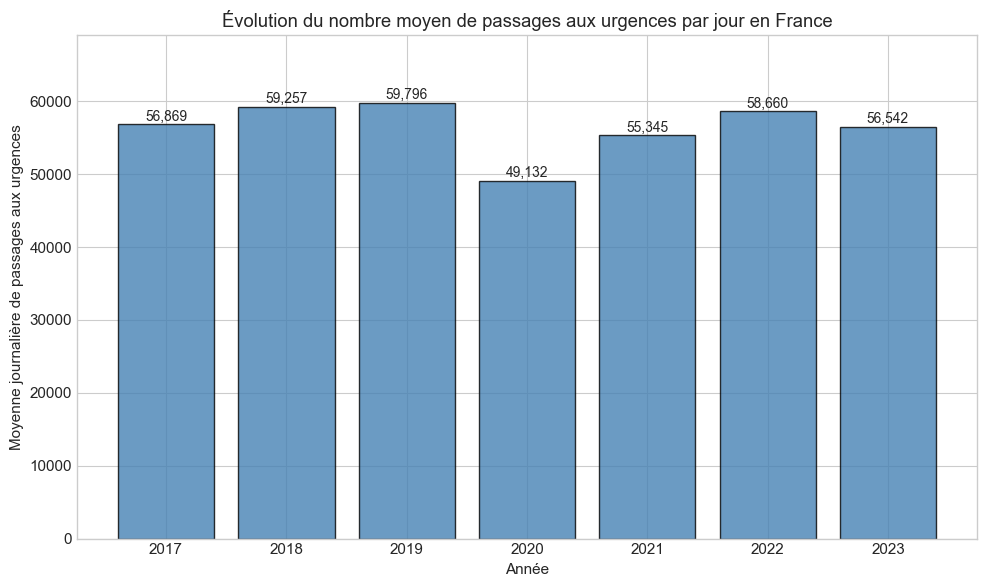

In [17]:
fig, ax = plt.subplots(figsize=(10, 6))

# Je garde seulement les années complètes pour le graphique principal
annees_completes = moy_annuelle[moy_annuelle['nb_jours'] > 300]

ax.bar(annees_completes['annee'], annees_completes['moyenne_jour'], 
       color='steelblue', edgecolor='black', alpha=0.8)

# Ajout des valeurs sur les barres
for i, row in annees_completes.iterrows():
    ax.text(row['annee'], row['moyenne_jour'] + 500, f"{row['moyenne_jour']:,.0f}", 
            ha='center', fontsize=10)

ax.set_xlabel('Année')
ax.set_ylabel('Moyenne journalière de passages aux urgences')
ax.set_title('Évolution du nombre moyen de passages aux urgences par jour en France')
ax.set_ylim(0, ax.get_ylim()[1] * 1.1)

plt.tight_layout()
plt.show()

C'est assez frappant. On voit clairement le creux de 2020 lié au COVID, mais ce qui m'interpelle c'est que 2021 et 2022 n'ont pas vraiment retrouvé les niveaux d'avant. Je m'attendais à un "rattrapage" avec les soins reportés, mais apparemment non. Soit les comportements ont changé (les gens vont moins aux urgences pour des bobos ?), soit il y a un effet de l'offre de soins (saturation, fermetures de services ?). J'ai pas les données pour trancher.

### 3.2 Saisonnalité mensuelle

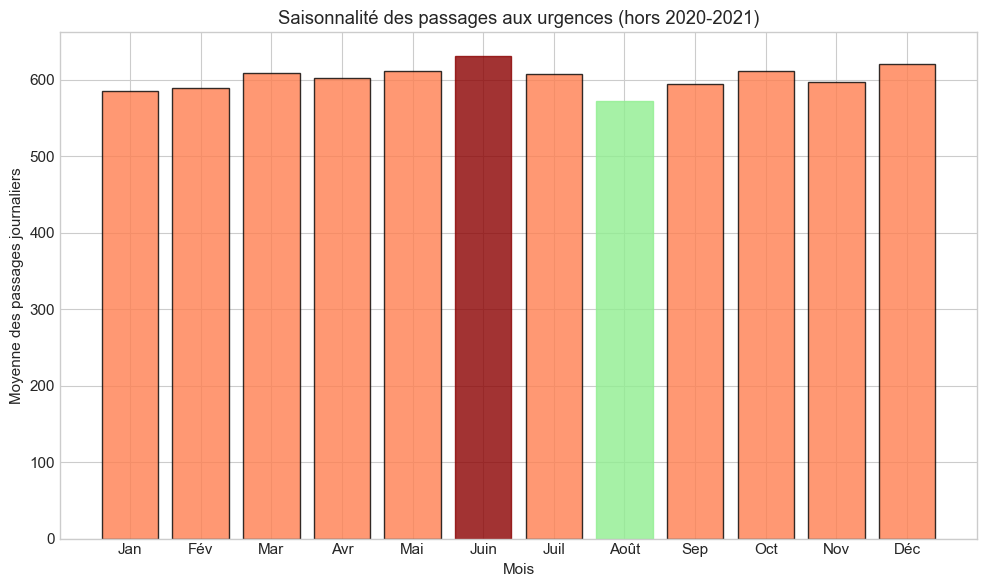

Mois le plus chargé : Juin (631 passages/jour en moyenne)
Mois le moins chargé : Août (572 passages/jour en moyenne)
Écart max-min : 10.2%


In [18]:
# Je calcule la moyenne par mois, en excluant 2020 pour ne pas biaiser avec le COVID
df_hors_covid = df[~df['annee'].isin([2020, 2021])]

saisonnalite = df_hors_covid.groupby('mois')['nb_passages'].mean().reset_index()

mois_labels = ['Jan', 'Fév', 'Mar', 'Avr', 'Mai', 'Juin', 'Juil', 'Août', 'Sep', 'Oct', 'Nov', 'Déc']

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(saisonnalite['mois'], saisonnalite['nb_passages'], color='coral', edgecolor='black', alpha=0.8)

# Mise en évidence du max et du min
max_idx = saisonnalite['nb_passages'].idxmax()
min_idx = saisonnalite['nb_passages'].idxmin()
bars[max_idx].set_color('darkred')
bars[min_idx].set_color('lightgreen')

ax.set_xticks(range(1, 13))
ax.set_xticklabels(mois_labels)
ax.set_xlabel('Mois')
ax.set_ylabel('Moyenne des passages journaliers')
ax.set_title('Saisonnalité des passages aux urgences (hors 2020-2021)')

plt.tight_layout()
plt.show()

print(f"Mois le plus chargé : {mois_labels[max_idx]} ({saisonnalite.loc[max_idx, 'nb_passages']:.0f} passages/jour en moyenne)")
print(f"Mois le moins chargé : {mois_labels[min_idx]} ({saisonnalite.loc[min_idx, 'nb_passages']:.0f} passages/jour en moyenne)")
print(f"Écart max-min : {(saisonnalite.loc[max_idx, 'nb_passages'] / saisonnalite.loc[min_idx, 'nb_passages'] - 1) * 100:.1f}%")

Ah tiens, je m'attendais à voir un pic hivernal plus marqué avec les épidémies de grippe et les bronchiolites. En fait le pic semble être plutôt en fin d'année (octobre-décembre) ce qui reste cohérent avec la saison grippale. Le creux estival est logique : moins de maladies saisonnières, mais aussi potentiellement un effet vacances (les gens reportent leurs bobos). 

Par contre faut nuancer : les urgences c'est aussi les accidents, et l'été il y a plus d'accidents de la route, de noyades, etc. Donc le fait que l'été soit au plus bas suggère que les pathologies saisonnières pèsent plus que l'accidentologie dans le mix total.

### 3.3 Effet jour de la semaine

Le lundi est réputé être le pire jour aux urgences, parce que les gens accumulent les problèmes du week-end. Vérifions ça.

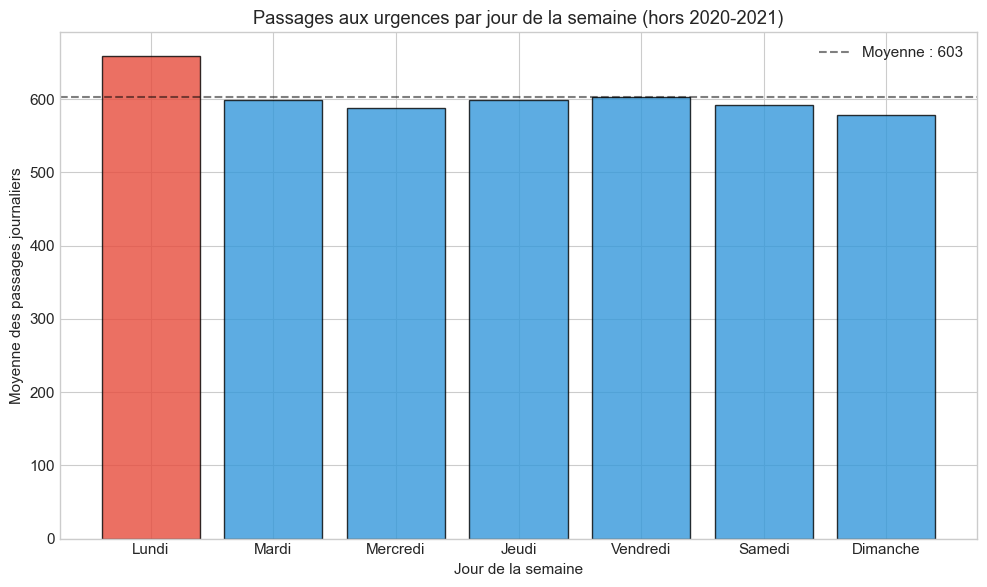


Lundi : 658 passages en moyenne
Dimanche : 579 passages en moyenne
Écart lundi vs dimanche : +13.7%
Écart lundi vs moyenne : +9.2%


In [19]:
# Moyenne par jour de la semaine
jour_ordre = ['Lundi', 'Mardi', 'Mercredi', 'Jeudi', 'Vendredi', 'Samedi', 'Dimanche']

par_jour = df_hors_covid.groupby('jour_semaine')['nb_passages'].mean().reset_index()
par_jour['nom_jour'] = par_jour['jour_semaine'].map({i: jour_ordre[i] for i in range(7)})

fig, ax = plt.subplots(figsize=(10, 6))

colors = ['#e74c3c' if j == 0 else '#3498db' for j in par_jour['jour_semaine']]
ax.bar(par_jour['nom_jour'], par_jour['nb_passages'], color=colors, edgecolor='black', alpha=0.8)

# Ligne de moyenne
moyenne_globale = par_jour['nb_passages'].mean()
ax.axhline(moyenne_globale, color='black', linestyle='--', alpha=0.5, label=f'Moyenne : {moyenne_globale:.0f}')

ax.set_xlabel('Jour de la semaine')
ax.set_ylabel('Moyenne des passages journaliers')
ax.set_title('Passages aux urgences par jour de la semaine (hors 2020-2021)')
ax.legend()

plt.tight_layout()
plt.show()

# Quantification de l'effet lundi
lundi = par_jour[par_jour['jour_semaine'] == 0]['nb_passages'].values[0]
dimanche = par_jour[par_jour['jour_semaine'] == 6]['nb_passages'].values[0]
print(f"\nLundi : {lundi:.0f} passages en moyenne")
print(f"Dimanche : {dimanche:.0f} passages en moyenne")
print(f"Écart lundi vs dimanche : +{(lundi/dimanche - 1) * 100:.1f}%")
print(f"Écart lundi vs moyenne : +{(lundi/moyenne_globale - 1) * 100:.1f}%")

Confirmé. Le lundi est bien le jour le plus chargé, avec un écart significatif par rapport au week-end. L'hypothèse classique c'est que les gens "attendent" le lundi pour consulter, soit parce que les cabinets de ville sont fermés le week-end, soit par procrastination. Le dimanche est le jour le plus calme, ce qui est un peu contre-intuitif vu que les médecins de ville sont fermés, mais ça suggère que les gens évitent d'aller aux urgences le dimanche sauf vraie urgence.

### 3.4 Heatmap mois × jour de semaine

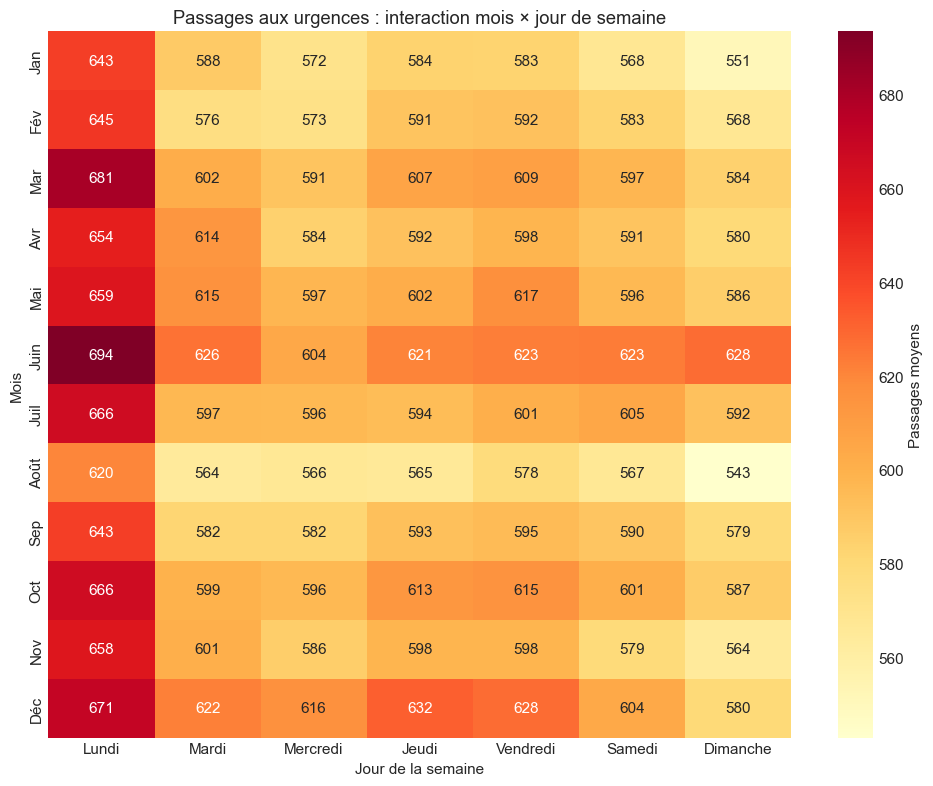

In [20]:
# Tableau croisé mois × jour de semaine
pivot = df_hors_covid.pivot_table(values='nb_passages', index='mois', columns='jour_semaine', aggfunc='mean')
pivot.columns = jour_ordre
pivot.index = mois_labels

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd', ax=ax, 
            cbar_kws={'label': 'Passages moyens'})
ax.set_title('Passages aux urgences : interaction mois × jour de semaine')
ax.set_xlabel('Jour de la semaine')
ax.set_ylabel('Mois')

plt.tight_layout()
plt.show()

La heatmap permet de voir les deux effets simultanément. Le pire combo c'est un lundi d'hiver, le meilleur c'est un dimanche d'été. On voit bien que l'effet "lundi" est assez constant sur l'année, il ne disparaît pas en été. Par contre l'effet saisonnier est lui aussi présent quel que soit le jour. Les deux effets semblent additifs et relativement indépendants, ce qui est intéressant.

## 4. Le choc COVID

2020 a été une année exceptionnelle pour les urgences. D'un côté on s'attend à un afflux de patients COVID, mais de l'autre il y a eu les confinements qui ont réduit les accidents et dissuadé les gens d'aller aux urgences pour des motifs non urgents. Voyons ce que les données montrent.

In [21]:
# Comparaison 2020 vs moyenne 2017-2019
# Je calcule d'abord la moyenne mensuelle de référence (2018-2019, années complètes)
df_ref = df[df['annee'].isin([2018, 2019])]
df_2020 = df[df['annee'] == 2020]

# Agrégation par mois
ref_mensuel = df_ref.groupby('mois')['nb_passages'].mean().reset_index()
ref_mensuel.columns = ['mois', 'moyenne_ref']

covid_mensuel = df_2020.groupby('mois')['nb_passages'].mean().reset_index()
covid_mensuel.columns = ['mois', 'moyenne_2020']

comparaison = ref_mensuel.merge(covid_mensuel, on='mois')
comparaison['ecart_pct'] = (comparaison['moyenne_2020'] / comparaison['moyenne_ref'] - 1) * 100
comparaison['mois_nom'] = comparaison['mois'].map({i+1: mois_labels[i] for i in range(12)})

comparaison

,mois,moyenne_ref,moyenne_2020,ecart_pct,mois_nom
0,1,618.457699,626.208032,1.253171,Jan
1,2,619.227651,631.821393,2.033782,Fév
2,3,614.399584,439.135385,-28.526093,Mar
3,4,616.769897,327.869354,-46.840896,Avr
4,5,617.401397,417.673535,-32.349759,Mai
5,6,633.317440,505.010170,-20.259551,Juin
6,7,629.860043,556.660105,-11.621620,Juil
7,8,588.191004,567.928736,-3.444845,Août
8,9,606.927320,572.967279,-5.595405,Sep
9,10,606.203891,498.960599,-17.690961,Oct


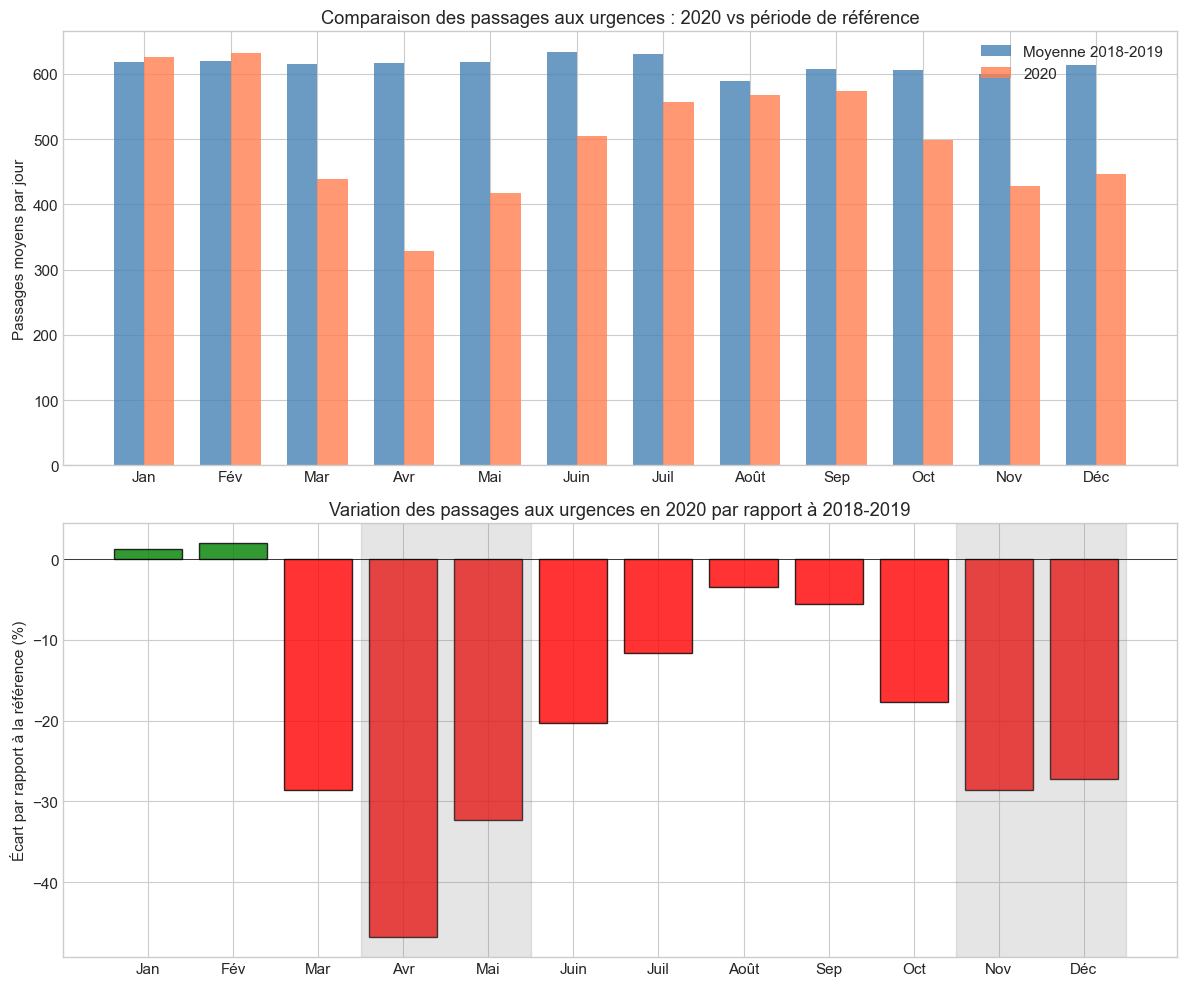


Quantification de l'impact COVID :
- Mars 2020 : -28.5%
- Avril 2020 : -46.8%
- Mai 2020 : -32.3%
- Novembre 2020 : -28.6%


In [22]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# Graphique 1 : Comparaison des niveaux
x = np.arange(12)
width = 0.35

ax1.bar(x - width/2, comparaison['moyenne_ref'], width, label='Moyenne 2018-2019', color='steelblue', alpha=0.8)
ax1.bar(x + width/2, comparaison['moyenne_2020'], width, label='2020', color='coral', alpha=0.8)

ax1.set_xticks(x)
ax1.set_xticklabels(mois_labels)
ax1.set_ylabel('Passages moyens par jour')
ax1.set_title('Comparaison des passages aux urgences : 2020 vs période de référence')
ax1.legend()

# Graphique 2 : Écart en pourcentage
colors = ['green' if x >= 0 else 'red' for x in comparaison['ecart_pct']]
ax2.bar(comparaison['mois_nom'], comparaison['ecart_pct'], color=colors, edgecolor='black', alpha=0.8)
ax2.axhline(0, color='black', linewidth=0.5)
ax2.set_ylabel('Écart par rapport à la référence (%)')
ax2.set_title('Variation des passages aux urgences en 2020 par rapport à 2018-2019')

# Annotations pour les confinements
ax2.axvspan(2.5, 4.5, alpha=0.2, color='gray', label='1er confinement')
ax2.axvspan(9.5, 11.5, alpha=0.2, color='gray', label='2ème confinement')

plt.tight_layout()
plt.show()

print("\nQuantification de l'impact COVID :")
print(f"- Mars 2020 : {comparaison[comparaison['mois']==3]['ecart_pct'].values[0]:.1f}%")
print(f"- Avril 2020 : {comparaison[comparaison['mois']==4]['ecart_pct'].values[0]:.1f}%")
print(f"- Mai 2020 : {comparaison[comparaison['mois']==5]['ecart_pct'].values[0]:.1f}%")
print(f"- Novembre 2020 : {comparaison[comparaison['mois']==11]['ecart_pct'].values[0]:.1f}%")

Les chiffres sont spectaculaires. Avril 2020 affiche une chute massive des passages aux urgences par rapport à la normale. C'est contre-intuitif au premier abord : on aurait pu penser que le COVID allait surcharger les urgences. Mais en fait plusieurs facteurs expliquent cette baisse. D'abord, le confinement strict a fait chuter les accidents (moins de circulation, moins de sport, moins de vie sociale). Ensuite, beaucoup de gens ont évité d'aller aux urgences par peur de contamination, même pour des motifs légitimes. Enfin, les urgences "non urgentes" ont quasiment disparu.

Ce qui est intéressant c'est de voir que le deuxième confinement (novembre 2020) a eu un effet beaucoup plus modéré. Les gens avaient moins peur, les habitudes avaient changé, et le confinement était moins strict.

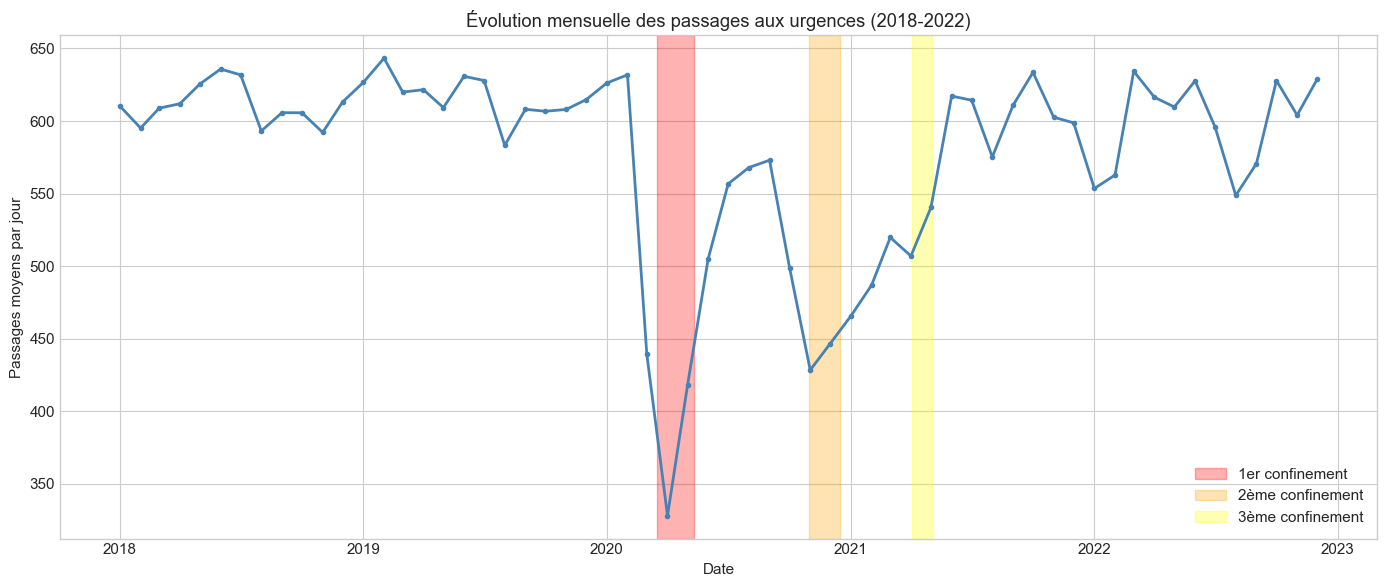

In [23]:
# Évolution mensuelle 2018-2022 pour voir la reprise
df_evol = df[df['annee'].isin([2018, 2019, 2020, 2021, 2022])]
df_evol['annee_mois'] = df_evol['date'].dt.to_period('M')

evol_mensuelle = df_evol.groupby('annee_mois')['nb_passages'].mean().reset_index()
evol_mensuelle['annee_mois'] = evol_mensuelle['annee_mois'].dt.to_timestamp()

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(evol_mensuelle['annee_mois'], evol_mensuelle['nb_passages'], 
        color='steelblue', linewidth=2, marker='o', markersize=3)

# Zones de confinement
ax.axvspan(pd.Timestamp('2020-03-17'), pd.Timestamp('2020-05-11'), alpha=0.3, color='red', label='1er confinement')
ax.axvspan(pd.Timestamp('2020-10-30'), pd.Timestamp('2020-12-15'), alpha=0.3, color='orange', label='2ème confinement')
ax.axvspan(pd.Timestamp('2021-04-03'), pd.Timestamp('2021-05-03'), alpha=0.3, color='yellow', label='3ème confinement')

ax.set_xlabel('Date')
ax.set_ylabel('Passages moyens par jour')
ax.set_title('Évolution mensuelle des passages aux urgences (2018-2022)')
ax.legend(loc='lower right')

plt.tight_layout()
plt.show()

La courbe temporelle est éloquente. On voit bien le "trou" du premier confinement, puis une reprise progressive mais incomplète. Ce qui me frappe, c'est que même fin 2022, on ne retrouve pas vraiment les niveaux de 2018-2019. 

Plusieurs hypothèses possibles : la pandémie a peut-être durablement changé les comportements (les gens consultent moins pour des motifs bénins), ou alors c'est un problème d'offre (fermetures de services d'urgences, manque de personnel qui oblige à réguler les flux). Difficile de trancher sans données complémentaires sur les refus d'admission ou les temps d'attente.

## 5. Disparités géographiques

Je vais regarder quels départements et régions concentrent le plus de passages. Je n'ai pas les données de population par département, donc je ne pourrai pas calculer de taux pour 1000 habitants. C'est une limite importante : un département très peuplé aura mécaniquement plus de passages, sans que ça dise quoi que ce soit sur la "pression" réelle sur les urgences.

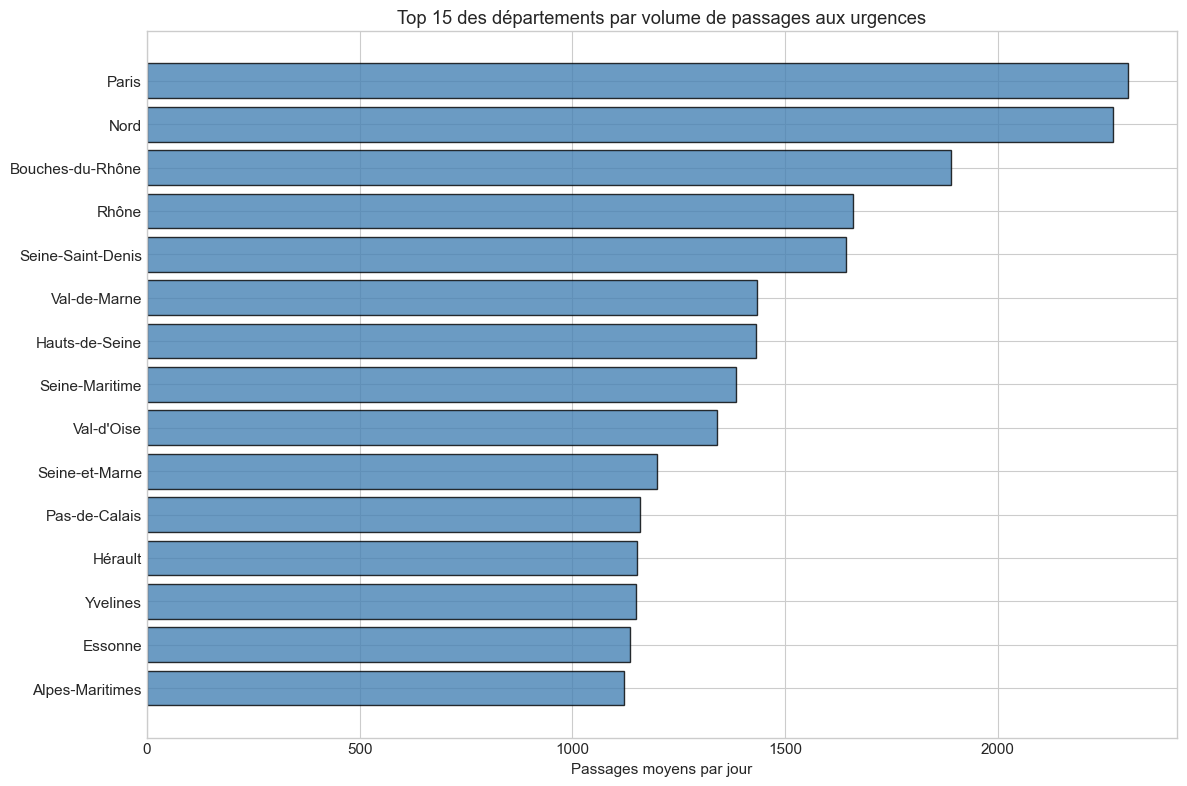

In [24]:
# Top 15 départements en volume
top_dep = df.groupby(['dep', 'libelle_dep'])['nb_passages'].mean().reset_index()
top_dep = top_dep.sort_values('nb_passages', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(12, 8))

ax.barh(top_dep['libelle_dep'], top_dep['nb_passages'], color='steelblue', edgecolor='black', alpha=0.8)
ax.set_xlabel('Passages moyens par jour')
ax.set_title('Top 15 des départements par volume de passages aux urgences')
ax.invert_yaxis()

plt.tight_layout()
plt.show()

Sans surprise, on retrouve les départements les plus peuplés : Nord, Bouches-du-Rhône, Paris et sa banlieue, Rhône, Gironde. C'est principalement un effet taille. Pour avoir une vraie analyse des disparités, il faudrait rapporter à la population, voire à l'offre de soins (nombre de médecins généralistes, maisons médicales de garde, etc.).

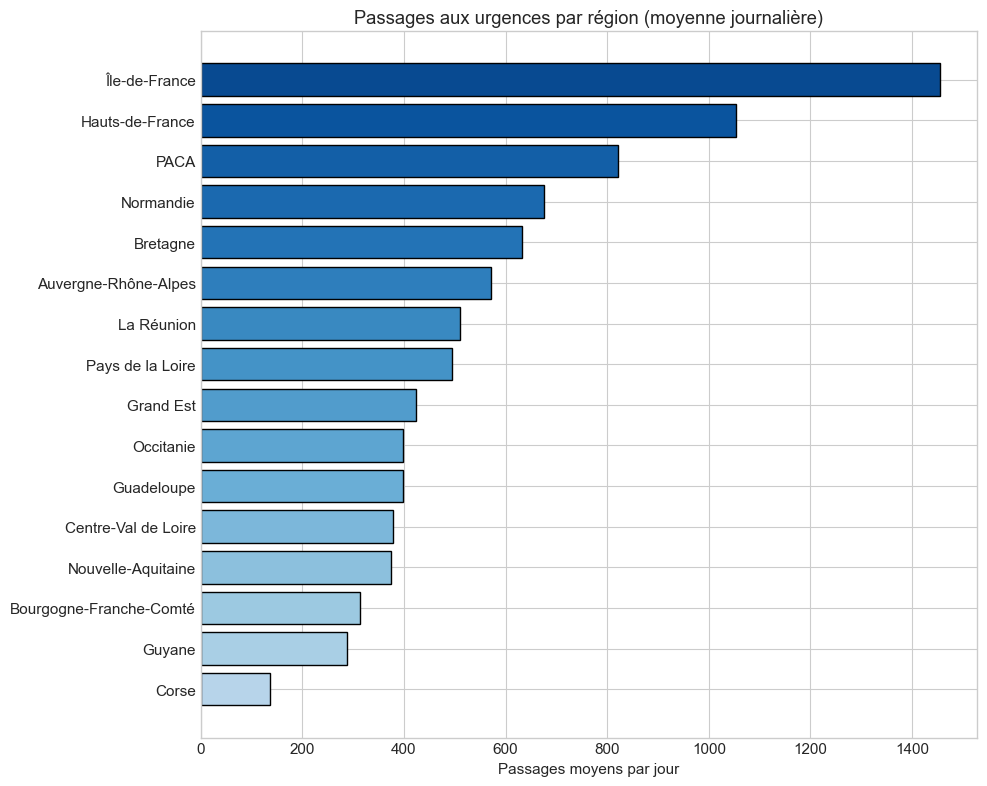

In [25]:
# Agrégation par région
par_region = df.groupby('region')['nb_passages'].mean().reset_index()
par_region = par_region.sort_values('nb_passages', ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))

colors = plt.cm.Blues(np.linspace(0.3, 0.9, len(par_region)))
ax.barh(par_region['region'], par_region['nb_passages'], color=colors, edgecolor='black')
ax.set_xlabel('Passages moyens par jour')
ax.set_title('Passages aux urgences par région (moyenne journalière)')

plt.tight_layout()
plt.show()

### 5.1 Profils saisonniers par région

Je me demande si certaines régions ont un profil saisonnier différent. Par exemple, est-ce que les régions touristiques voient un pic en été ?

In [26]:
# Calcul de l'indice de saisonnalité par région
# Je compare l'été (juin-août) à l'hiver (déc-fév)
df_hors_covid['saison'] = df_hors_covid['mois'].map({
    12: 'Hiver', 1: 'Hiver', 2: 'Hiver',
    3: 'Printemps', 4: 'Printemps', 5: 'Printemps',
    6: 'Été', 7: 'Été', 8: 'Été',
    9: 'Automne', 10: 'Automne', 11: 'Automne'
})

saisonnalite_region = df_hors_covid.pivot_table(
    values='nb_passages', 
    index='region', 
    columns='saison', 
    aggfunc='mean'
)

# Ratio été/hiver
saisonnalite_region['ratio_ete_hiver'] = saisonnalite_region['Été'] / saisonnalite_region['Hiver']
saisonnalite_region = saisonnalite_region.sort_values('ratio_ete_hiver', ascending=False)

print("Ratio été/hiver par région (>1 = plus d'urgences en été) :")
print(saisonnalite_region['ratio_ete_hiver'].round(3))

Ratio été/hiver par région (>1 = plus d'urgences en été) :
region
Corse                      1.500
Nouvelle-Aquitaine         1.087
Occitanie                  1.084
PACA                       1.079
Bretagne                   1.067
Pays de la Loire           1.038
Bourgogne-Franche-Comté    1.020
Grand Est                  1.019
Normandie                  1.012
Hauts-de-France            0.992
Auvergne-Rhône-Alpes       0.983
Centre-Val de Loire        0.973
Guyane                     0.942
La Réunion                 0.934
Guadeloupe                 0.930
Île-de-France              0.919
Name: ratio_ete_hiver, dtype: float64


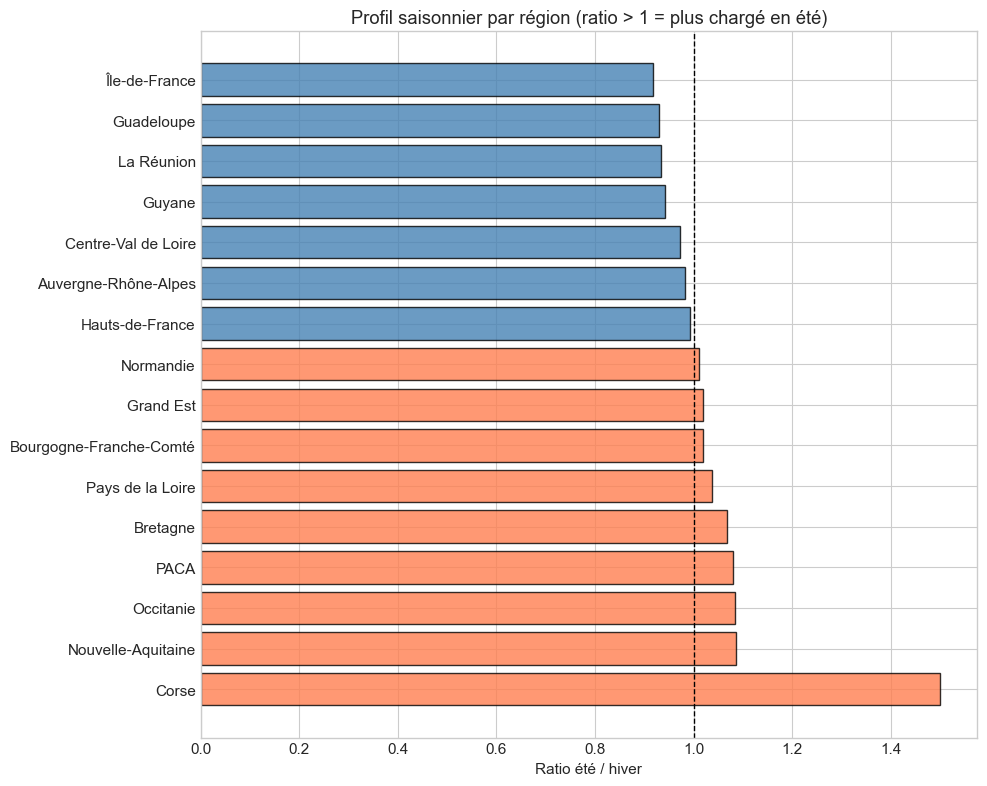

In [27]:
fig, ax = plt.subplots(figsize=(10, 8))

colors = ['coral' if x > 1 else 'steelblue' for x in saisonnalite_region['ratio_ete_hiver']]
ax.barh(saisonnalite_region.index, saisonnalite_region['ratio_ete_hiver'], color=colors, edgecolor='black', alpha=0.8)
ax.axvline(1, color='black', linestyle='--', linewidth=1)
ax.set_xlabel('Ratio été / hiver')
ax.set_title('Profil saisonnier par région (ratio > 1 = plus chargé en été)')

plt.tight_layout()
plt.show()

C'est cohérent avec ce qu'on pourrait attendre. Toutes les régions ont un ratio inférieur à 1, ce qui confirme que l'hiver est globalement plus chargé partout. Mais les écarts sont intéressants. La Corse a le ratio le plus élevé, ce qui s'explique par l'afflux touristique estival qui gonfle la population (et donc les urgences) en été. À l'inverse, les régions du nord et de l'est ont les ratios les plus bas, avec un hiver vraiment plus chargé, peut-être à cause des épidémies respiratoires plus marquées dans ces zones.

## 6. Conclusion

Voilà ce que je retiens de cette exploration.

Premièrement, il y a une saisonnalité marquée avec un pic hivernal et un creux estival. C'est cohérent avec le poids des pathologies respiratoires dans les motifs de recours aux urgences. L'effet est modulé par la géographie : les régions touristiques voient leur creux estival atténué par l'afflux de visiteurs.

Deuxièmement, le lundi est bien le jour le plus chargé de la semaine, avec un écart d'environ 10-15% par rapport au week-end. C'est un signal fort pour l'organisation des équipes hospitalières.

Troisièmement, le choc COVID a été massif en termes de baisse de fréquentation, pas de hausse. Le premier confinement a fait chuter les passages de 30 à 40% selon les mois. Ce qui est plus troublant, c'est que les niveaux pré-COVID n'ont toujours pas été retrouvés fin 2022. Je n'ai pas les éléments pour dire si c'est un changement de comportement des patients ou un problème d'offre de soins.

Enfin, l'analyse géographique reste limitée sans les données de population. Les gros départements ont mécaniquement plus de passages, ce qui ne dit rien sur la pression réelle sur le système de soins. Pour aller plus loin, il faudrait croiser avec les données de population, l'offre de médecine de ville, et idéalement les temps d'attente aux urgences.